In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px  # interactive figures
import plotly.graph_objects as go
import seaborn as sns


In [2]:
import pandas as pd

df = pd.read_csv("../data_raw/date_24_art_loreal_20%.csv")

df = df[df["ID_ARTICOL"] == 144602]

df.head()

,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
0,01-Jan-24,144602,"CERAVE CREMA HIDRATANTA DE FATA SPF 50, TEN NO...",0,0.00,0.0,0.00,0.0,0.0,0.00,84,84,0
15,02-Jan-24,144602,"CERAVE CREMA HIDRATANTA DE FATA SPF 50, TEN NO...",0,0.00,0.0,0.00,0.0,0.0,0.00,84,84,0
27,03-Jan-24,144602,"CERAVE CREMA HIDRATANTA DE FATA SPF 50, TEN NO...",7,388.21,462.0,333.95,0.0,0.0,54.26,84,77,0
46,04-Jan-24,144602,"CERAVE CREMA HIDRATANTA DE FATA SPF 50, TEN NO...",8,443.69,528.0,395.20,0.0,0.0,48.49,77,119,0
53,05-Jan-24,144602,"CERAVE CREMA HIDRATANTA DE FATA SPF 50, TEN NO...",14,776.42,924.0,691.60,0.0,0.0,84.82,119,105,0


standard deviation is a way to measure how "spread out" or "different" the values in a group are from the average.

If the standard deviation is small, it means most values are close to the average (not much variation).
If the standard deviation is large, it means the values are spread out and vary a lot from the average.

Conversie coloana data din object in datetime

In [3]:
df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")

C:\Users\Mara\AppData\Local\Temp\ipykernel_29960\2340964975.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 735 entries, 0 to 9987
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DATA                  735 non-null    datetime64[ns]
 1   ID_ARTICOL            735 non-null    int64         
 2   ARTICOL               735 non-null    object        
 3   CANTITATE             735 non-null    int64         
 4   VAL_IESIRE_FARA_TVA   735 non-null    float64       
 5   VAL_IESIRE_CU_TVA     735 non-null    float64       
 6   VAL_INTRARE_FARA_TVA  735 non-null    float64       
 7   TOTAL_DISCOUNT        735 non-null    float64       
 8   RATA_DISCOUNT         705 non-null    float64       
 9   ADAOS                 735 non-null    float64       
 10  STOC_INITIAL          735 non-null    int64         
 11  STOC_FINAL            735 non-null    int64         
 12  RUPTURA_STOC          735 non-null    int64         
dtypes: datetime64[ns](1), fl

In [5]:
# Sortare logică pentru time series
df = df.sort_values(by=["DATA"]).reset_index(drop=True)

In [6]:
# reguli de calitate
checks = {}

# 1) vânzare > 0 dar valoare = 0 (suspect)
checks["qty_pos_val_zero"] = df[(df["CANTITATE"] > 0) & (df["VAL_IESIRE_CU_TVA"] == 0)]

# 2) valoare > 0 dar cantitate = 0 (suspect)
checks["val_pos_qty_zero"] = df[(df["VAL_IESIRE_CU_TVA"] > 0) & (df["CANTITATE"] == 0)]

# 3) stoc final negativ (dacă există în dataset)
if "STOC_FINAL" in df.columns:
    checks["stoc_final_negativ"] = df[df["STOC_FINAL"] < 0]

# 4) discount > 0 dar rata_discount = 0 (suspect)
if "TOTAL_DISCOUNT" in df.columns and "RATA_DISCOUNT" in df.columns:
    checks["disc_pos_rata_zero"] = df[(df["TOTAL_DISCOUNT"] > 0) & (df["RATA_DISCOUNT"] == 0)]

# 5) 
checks["stockout_start"] = df[(df["STOC_INITIAL"] == 0) & (df["CANTITATE"] == 0)]
checks["no_sales_but_in_stock"] = df[(df["STOC_INITIAL"] > 0) & (df["CANTITATE"] == 0)]

{k: v.shape[0] for k, v in checks.items()}

{'qty_pos_val_zero': 0,
 'val_pos_qty_zero': 0,
 'stoc_final_negativ': 0,
 'disc_pos_rata_zero': 0,
 'stockout_start': 0,
 'no_sales_but_in_stock': 33}

In [7]:
cols = ["CANTITATE", "STOC_INITIAL", "STOC_FINAL", "VAL_IESIRE_FARA_TVA"]

(df[cols] < 0).sum()


CANTITATE              0
STOC_INITIAL           0
STOC_FINAL             0
VAL_IESIRE_FARA_TVA    0
dtype: int64

In [8]:
# df = df.set_index('DATA') 

In [9]:
# df

Pentru evitarea redundanței informaționale, variabilele puternic corelate vor fi filtrate.  ( gen val iesire cu fara tva, total discount - rata discount )

In [10]:
df_feat = df.drop(columns=[ "STOC_FINAL", "RUPTURA_STOC", "VAL_IESIRE_CU_TVA", "RATA_DISCOUNT", "ARTICOL"])

df_feat


,DATA,ID_ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL
0,2024-01-01,144602,0,0.00,0.00,0.0,0.00,84
1,2024-01-02,144602,0,0.00,0.00,0.0,0.00,84
2,2024-01-03,144602,7,388.21,333.95,0.0,54.26,84
3,2024-01-04,144602,8,443.69,395.20,0.0,48.49,77
4,2024-01-05,144602,14,776.42,691.60,0.0,84.82,119
...,...,...,...,...,...,...,...,...
730,2025-12-31,144602,0,0.00,0.00,0.0,0.00,156
731,2026-01-01,144602,0,0.00,0.00,0.0,0.00,156
732,2026-01-02,144602,0,0.00,0.00,0.0,0.00,156
733,2026-01-03,144602,5,311.98,273.15,0.0,38.83,156


# XGBoost

### Feature Engineering

In [11]:

df_feat["DOW"] = df_feat["DATA"].dt.dayofweek          # 0..6
df_feat["month"] = df_feat["DATA"].dt.month
df_feat["ESTE_WEEKEND"] = (df_feat["DOW"] >= 5).astype(int)

# dacă ai deja LUNA ca yyyy-mm, păstreaz-o ca perioadă (opțional)
# df_feat["YYYY_MM"] = df_feat["DATA"].dt.to_period("M").astype(str)

# opțional: zi din lună (uneori surprinde patternuri de început/sfârșit)
df_feat["ZI_DIN_LUNA"] = df_feat["DATA"].dt.day

# lag-uri din target
for lag in [1, 7, 14, 21]:
    df_feat[f"lag_{lag}"] = df_feat["CANTITATE"].shift(lag)

# rolling (folosește shift(1) ca să eviți leakage!)
df_feat["roll_mean_7"] = df_feat["CANTITATE"].shift(1).rolling(7).mean()
df_feat["roll_mean_14"] = df_feat["CANTITATE"].shift(1).rolling(14).mean()
df_feat["roll_std_7"] = df_feat["CANTITATE"].shift(1).rolling(7).std()


df_feat


,DATA,ID_ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL,DOW,month,ESTE_WEEKEND,ZI_DIN_LUNA,lag_1,lag_7,lag_14,lag_21,roll_mean_7,roll_mean_14,roll_std_7
0,2024-01-01,144602,0,0.00,0.00,0.0,0.00,84,0,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,144602,0,0.00,0.00,0.0,0.00,84,1,1,0,2,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,144602,7,388.21,333.95,0.0,54.26,84,2,1,0,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,144602,8,443.69,395.20,0.0,48.49,77,3,1,0,4,7.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,144602,14,776.42,691.60,0.0,84.82,119,4,1,0,5,8.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,2025-12-31,144602,0,0.00,0.00,0.0,0.00,156,2,12,0,31,3.0,3.0,3.0,1.0,2.285714,3.785714,2.429972
731,2026-01-01,144602,0,0.00,0.00,0.0,0.00,156,3,1,0,1,0.0,0.0,3.0,2.0,1.857143,3.571429,2.544836
732,2026-01-02,144602,0,0.00,0.00,0.0,0.00,156,4,1,0,2,0.0,0.0,7.0,3.0,1.857143,3.357143,2.544836
733,2026-01-03,144602,5,311.98,273.15,0.0,38.83,156,5,1,1,3,0.0,1.0,5.0,3.0,1.857143,2.857143,2.544836


In [12]:
fig = px.line(df, x='DATA', y='CANTITATE', title='Time Series with Range Slider and Selectors')

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            # dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig.update_layout(width=1100, height=500)
fig.show()

In [13]:
split_idx = int(len(df_feat) * 0.8)
train_df = df_feat.iloc[:split_idx].copy()
test_df  = df_feat.iloc[split_idx:].copy()

# opțional: scoți din TRAIN zilele de stock-out (corect pentru cerere)
if "STOC_INITIAL" in train_df.columns:
    train_df = train_df[~((train_df["STOC_INITIAL"] == 0) & (train_df["CANTITATE"] == 0))].copy()


In [14]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target = "CANTITATE"
drop_cols = ["DATA", target]
X_cols = [c for c in train_df.columns if c not in drop_cols]

xgb = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)

xgb.fit(train_df[X_cols], train_df[target])
pred_xgb = xgb.predict(test_df[X_cols])

y_true = test_df[target].values
mae = mean_absolute_error(y_true, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_true, pred_xgb))
r2 = r2_score(y_true, pred_xgb)

mae, rmse, r2


(0.12873074412345886, np.float64(1.0427143486731023), 0.9690018892288208)

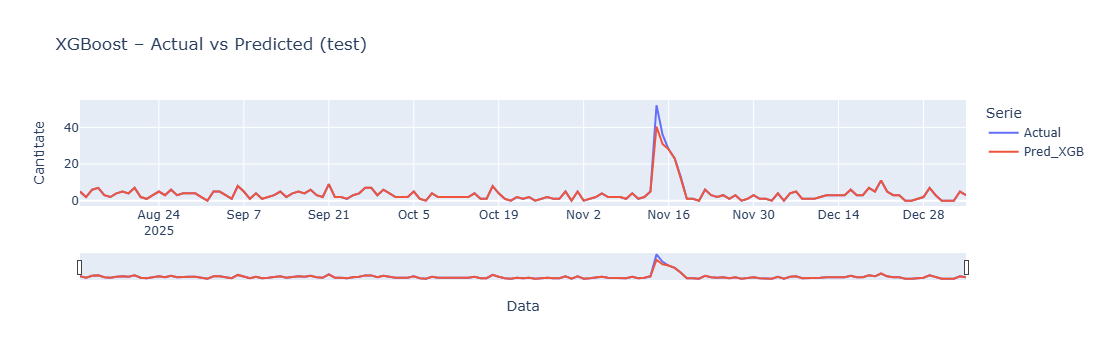

In [15]:
import plotly.express as px

df_plot = pd.DataFrame({
    "DATA": test_df["DATA"].values,
    "Actual": y_true,
    "Pred_XGB": pred_xgb
})

df_long = df_plot.melt("DATA", var_name="Serie", value_name="Cantitate")
fig = px.line(df_long, x="DATA", y="Cantitate", color="Serie",
              title="XGBoost – Actual vs Predicted (test)")
fig.update_layout(hovermode="x unified", xaxis_title="Data", yaxis_title="Cantitate")
fig.update_xaxes(rangeslider_visible=True)
fig.show()
